# IDS Stage 1 - Adapted for nDPI CSV Format
Détection d'anomalies sur données de flux réseau nDPI

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from IPython.display import display, Markdown

from pathlib import Path
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Style visuel homogène pour des figures prêtes à capturer
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.titlepad": 12,
})

## 1. LOAD DATA

In [30]:
DATASET_PATH = Path("csv/processed/labelled_dataset.csv")

In [31]:
# =========================
# ======= DATA LOAD =======
# =========================

df = pd.read_csv(DATASET_PATH)

if "label" not in df.columns:
    raise ValueError("Expected a 'label' column in the dataset.")

lab = df["label"].astype(str).str.strip().str.upper()
mapped = lab.map({"BENIGN": 0, "MALICIOUS": 1})
numeric = pd.to_numeric(df["label"], errors="coerce")
df["label"] = mapped.fillna(numeric).fillna(0).astype(int)

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["label"],
)

train_benign_df = train_df[train_df["label"] == 0].copy()

# ===== Résumé dataset (affichage amélioré) =====
total_rows, total_cols = df.shape
train_rows, test_rows = train_df.shape[0], test_df.shape[0]
benign_train = (train_df["label"] == 0).sum()
mal_train = (train_df["label"] == 1).sum()

missing_total = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())
memory_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)

num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

label_counts = df["label"].value_counts().sort_index()
label_ratio = (df["label"].value_counts(normalize=True).sort_index() * 100).round(2)

print("=" * 60)
print("CHARGEMENT DES DONNÉES")
print("=" * 60)
print(f"Fichier            : {DATASET_PATH}")
print(f"Lignes / Colonnes  : {total_rows:,} / {total_cols}")
print(f"Mémoire estimée    : {memory_mb:.2f} MB")
print()

print("Split train/test")
print(f"- Train (70%)      : {train_rows:,}")
print(f"- Test  (30%)      : {test_rows:,}")
print()

print("Répartition train")
print(f"- Benign (label=0) : {benign_train:,}")
print(f"- Malicious (1)    : {mal_train:,}")
print()

print("Distribution des labels (dataset complet)")
for cls in sorted(label_counts.index):
    print(f"- label {cls}: {label_counts[cls]:,} ({label_ratio[cls]:.2f}%)")
print()

print("Qualité des données")
print(f"- Valeurs manquantes (total): {missing_total:,}")
print(f"- Lignes dupliquées          : {duplicate_rows:,}")
print(f"- Colonnes numériques        : {len(num_cols)}")
print(f"- Colonnes non numériques    : {len(cat_cols)}")

# Top colonnes avec valeurs manquantes (si présent)
missing_by_col = df.isna().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)
if not missing_by_col.empty:
    print("\nTop colonnes avec NaN:")
    print(missing_by_col.head(10))


CHARGEMENT DES DONNÉES
Fichier            : csv/processed/labelled_dataset.csv
Lignes / Colonnes  : 7,285 / 60
Mémoire estimée    : 9.31 MB

Split train/test
- Train (70%)      : 5,099
- Test  (30%)      : 2,186

Répartition train
- Benign (label=0) : 3,061
- Malicious (1)    : 2,038

Distribution des labels (dataset complet)
- label 0: 4,373 (60.03%)
- label 1: 2,912 (39.97%)

Qualité des données
- Valeurs manquantes (total): 50,293
- Lignes dupliquées          : 0
- Colonnes numériques        : 47
- Colonnes non numériques    : 13

Top colonnes avec NaN:
srcCountry                7285
dstCountry                7285
srcOrg                    7285
dstOrg                    7285
dstDomain                 7285
srcDomain                 7285
stddevPacketLength        5677
interArrivalTimeStdDev     328
dstPort                    289
srcPort                    289
dtype: int64


In [32]:
# Data preview
print("Train split preview:")
train_df.head()


Train split preview:


,id,flowKey,firstSeen,lastSeen,srcIp,dstIp,srcPort,dstPort,protocol,bytes,packets,packetSummaries,treatmentDelay,durationMs,reasonOfFlowEnd,minPacketLength,maxPacketLength,meanPacketLength,stddevPacketLength,bytesPerSecond,packetsPerSecond,totalBytesUpstream,totalBytesDownstream,totalPacketsUpstream,totalPacketsDownstream,ratioBytesUpDown,ratioPacketsUpDown,flowDurationMs,interArrivalTimeMean,interArrivalTimeStdDev,interArrivalTimeMin,interArrivalTimeMax,flowSymmetry,synRate,finRate,rstRate,ackRate,pshRate,synCount,finCount,rstCount,ackCount,pshCount,tcpFraction,udpFraction,otherFraction,appProtocolBytes,appProtocol,riskLevel,riskMask,riskLabel,riskSeverity,ndpiFlowPtr,srcCountry,dstCountry,srcDomain,dstDomain,srcOrg,dstOrg,label
2923,d4d94297-c218-4203-9013-72780353a965,192.168.1.12_192.168.1.5_48814_21_TCP,2026-03-09 08:25:29.666000000,2026-03-09 08:25:29.666000000,192.168.1.12,192.168.1.5,"48,814.0000",21.0000,TCP,74,1,{'P_192.168.1.12_192.168.1.5_TCP_SYN_177304472...,{170},0,Inactivity Timeout,74,74,74.0000,NaN,0.0000,0.0000,74.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1,0,0,0,0,1.0000,0.0000,0.0000,0.0000,nDPI not initialized,-1,-1,{'No risk'},No risk,139054735367264,NaN,NaN,NaN,NaN,NaN,NaN,0
4079,e8e19124-94bd-401a-b04c-c42a02748540,192.168.1.12_192.168.1.5_34634_21_TCP,2026-03-09 16:43:30.347000000,2026-03-09 16:43:41.561000000,192.168.1.12,192.168.1.5,"34,634.0000",21.0000,TCP,592,8,{'P_192.168.1.12_192.168.1.5_TCP_SYN_177307461...,"{277,278,280,280,280,280,280,280}",11214,Inactivity Timeout,74,74,74.0000,0.0000,52.7912,0.7134,592.0000,0.0000,8.0000,0.0000,1.0000,1.0000,"11,214.0000","1,602.0000","1,137.1220","1,023.0000","4,032.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,8,0,0,0,0,1.0000,0.0000,0.0000,0.0000,nDPI not initialized,-1,-1,{'No risk'},No risk,139054668269600,NaN,NaN,NaN,NaN,NaN,NaN,0
5920,81e7472e-95e3-48f8-bd67-3f5dca7342ae,192.168.1.10_192.168.1.6_51515_53_UDP,2026-03-10 15:14:45.798000000,2026-03-10 15:14:45.798000000,192.168.1.10,192.168.1.6,"51,515.0000",53.0000,UDP,93,1,{'P_192.168.1.10_192.168.1.6_UDP__1773155685798'},{469},0,Inactivity Timeout,93,93,93.0000,NaN,0.0000,0.0000,93.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0,0,0,0,0,0.0000,1.0000,0.0000,0.0000,nDPI not initialized,-1,-1,{'No risk'},No risk,125554109681104,NaN,NaN,NaN,NaN,NaN,NaN,1
2540,364ec0df-3534-4fab-9e56-a09fa9d5aab4,192.168.1.12_192.168.1.5_null_null_ICMPv4,2026-03-09 05:40:23.626000000,2026-03-09 05:40:23.626000000,192.168.1.12,192.168.1.5,NaN,NaN,ICMPv4,196,2,{'P_192.168.1.12_192.168.1.5_ICMPv4__177303482...,"{35,35}",0,Inactivity Timeout,98,98,98.0000,0.0000,0.0000,0.0000,98.0000,98.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,NaN,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,-1.0000,0,0,0,0,0,0.0000,0.0000,1.0000,0.0000,nDPI not initialized,-1,-1,{'No risk'},No risk,139054602331472,NaN,NaN,NaN,NaN,NaN,NaN,0
4336,ef58b1a8-9481-4338-8c96-d14e7dc292a0,192.168.1.12_192.168.1.5_45282_8080_TCP,2026-03-09 18:29:49.980000000,2026-03-09 18:30:01.203000000,192.168.1.12,192.168.1.5,"45,282.0000","8,080.0000",TCP,592,8,{'P_192.168.1.12_192.168.1.5_TCP_SYN_177308098...,"{322,323,323,323,323,323,323,323}",11223,Inactivity Timeout,74,74,74.0000,0.0000,52.7488,0.7128,592.0000,0.0000,8.0000,0.0000,1.0000,1.0000,"11,223.0000","1,603.2858","1,136.3806","1,024.0000","4,032.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,8,0,0,0,0,1.0000,0.0000,0.0000,0.0000,nDPI not initialized,-1,-1,{'No risk'},No risk,139054869926688,NaN,NaN,NaN,NaN,NaN,NaN,0


In [33]:
# Column information
print("Dataset info:")
df.info()


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7285 entries, 0 to 7284
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      7285 non-null   str    
 1   flowKey                 7285 non-null   str    
 2   firstSeen               7285 non-null   str    
 3   lastSeen                7285 non-null   str    
 4   srcIp                   7285 non-null   str    
 5   dstIp                   7285 non-null   str    
 6   srcPort                 6996 non-null   float64
 7   dstPort                 6996 non-null   float64
 8   protocol                7285 non-null   str    
 9   bytes                   7285 non-null   int64  
 10  packets                 7285 non-null   int64  
 11  packetSummaries         7285 non-null   str    
 12  treatmentDelay          7285 non-null   str    
 13  durationMs              7285 non-null   int64  
 14  reasonOfFlowEnd         7285 non-null

## 2. FEATURE SELECTION - Features nDPI pertinentes

In [34]:
# =========================
# ======= FEATURES ========
# =========================
FEATURE_COLUMNS = [
    c for c in df.columns
    if c != "label" and not c.startswith("container")
]

print(f"Total feature columns: {len(FEATURE_COLUMNS)}")


Total feature columns: 59


In [35]:
# =========================
# ======= FEATURES =======
# =========================
BASE_FEATURES = [
    'bytes', 'packets',
    'minPacketLength', 'maxPacketLength', 'meanPacketLength', 'stddevPacketLength',
    'bytesPerSecond', 'packetsPerSecond',
    'totalBytesUpstream', 'totalBytesDownstream', 'totalPacketsUpstream', 'totalPacketsDownstream',
    'interArrivalTimeMean', 'interArrivalTimeStdDev', 'interArrivalTimeMin', 'interArrivalTimeMax',
    'synCount', 'finCount', 'rstCount', 'ackCount', 'pshCount',
    'flowDurationMs', 'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate','durationMs',
]

DERIVED_FEATURES = [
    'avgPacketIntervalMs',
    'synFinDiff',
    'ackRatePerMs',
    'iatMaxToMeanRatio'
]

COLUMNS_TO_DROP = [
    'id', 'flowKey', 'firstSeen', 'lastSeen', 'srcIp', 'dstIp',
    'srcPort', 'dstPort', 'packetSummaries', 'treatmentDelay',
    'reasonOfFlowEnd', 'appProtocolBytes', 'appProtocol',
    'riskLevel', 'riskMask', 'riskLabel', 'riskSeverity',
    'ndpiFlowPtr', 'srcCountry', 'dstCountry', 'srcDomain',
    'dstDomain', 'srcOrg', 'dstOrg', 
    # On supprime ces colonnes si elles existent dans les données d’origine
    'ratioBytesUpDown', 'ratioPacketsUpDown', 'flowSymmetry',
    
    'tcpFraction', 'udpFraction', 'otherFraction'
]

FEATURE_COLUMNS = BASE_FEATURES + DERIVED_FEATURES

print("=" * 60)
print("INFORMATION SUR LES ATTRIBUTS")
print("=" * 60)
print(f"Total des attributs dans le dataset : {len(df.columns)}")
print(f"Total des features utilisées       : {len(FEATURE_COLUMNS)}")
print(f"Colonnes de base (features): {len(BASE_FEATURES)}")
print(f"Colonnes dérivées (features): {len(DERIVED_FEATURES)}")

INFORMATION SUR LES ATTRIBUTS
Total des attributs dans le dataset : 60
Total des features utilisées       : 32
Colonnes de base (features): 28
Colonnes dérivées (features): 4


## 3. DATA PREPROCESSING

In [36]:
# =========================
# ===== PREPROCESS ========
# =========================
def preprocess(df):
    df = df.copy()

    # 1) Drop colonnes inutiles
    for col in COLUMNS_TO_DROP:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # 2) Colonnes de base: assurer présence + numérique + NaN -> 0
    for col in BASE_FEATURES:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df[BASE_FEATURES] = df[BASE_FEATURES].fillna(0)

    # 3) Clip négatif (au cas où)
    for col in BASE_FEATURES:
        df[col] = df[col].clip(lower=0)

    # 4) Eviter divisions par zéro
    small = 1e-6
    safe = ['flowDurationMs', 'interArrivalTimeMean',
            'totalPacketsUpstream', 'totalPacketsDownstream']
    for col in safe:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        df[col] = df[col].replace(0, small)

    # 5) Features dérivées (créées à partir des colonnes de base)
    df['avgPacketIntervalMs'] = df['flowDurationMs'] / (df['totalPacketsUpstream'] + df['totalPacketsDownstream'] + small)
    df['synFinDiff'] = (pd.to_numeric(df.get('synCount', 0), errors='coerce').fillna(0)
                        - pd.to_numeric(df.get('finCount', 0), errors='coerce').fillna(0))
    df['ackRatePerMs'] = pd.to_numeric(df.get('ackCount', 0), errors='coerce').fillna(0) / (df['flowDurationMs'] + small)
    df['iatMaxToMeanRatio'] = pd.to_numeric(df.get('interArrivalTimeMax', 0), errors='coerce').fillna(0) / (df['interArrivalTimeMean'] + small)

    # 6) Colonnes dérivées listées (si tu en as une liste formelle)
    for col in DERIVED_FEATURES:
        if col not in df.columns:
            # Si DERIVED_FEATURES inclut des colonnes qu'on n'a pas créées ci-dessus,
            # on les ajoute à 0 par défaut
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # 7) Nettoyage final: inf -> 0, NaN -> 0
    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)

    return df

# ----- Application au train/test en gardant les mêmes noms de variables -----

# Prétraitement des DataFrames sources
train_benign_df_proc = preprocess(train_benign_df)
test_df_proc         = preprocess(test_df)

# Définition de l'ensemble final de features utilisées pour X
# (on suppose que FEATURE_COLUMNS correspond maintenant à BASE_FEATURES + DERIVED_FEATURES.
# Si tu as déjà une liste FEATURE_COLUMNS cohérente avec la nouvelle logique, réutilise-la.)
FEATURE_COLUMNS_FINAL = list(dict.fromkeys(list(BASE_FEATURES) + list(DERIVED_FEATURES)))

# Construire X_* avec les mêmes noms qu'avant
# (si certaines colonnes manquent malgré tout, on les crée à 0 pour garantir la même forme)
for col in FEATURE_COLUMNS_FINAL:
    if col not in train_benign_df_proc.columns:
        train_benign_df_proc[col] = 0
    if col not in test_df_proc.columns:
        test_df_proc[col] = 0

X_train_benign = train_benign_df_proc[FEATURE_COLUMNS_FINAL].copy()
X_test         = test_df_proc[FEATURE_COLUMNS_FINAL].copy()

# y_test binaire robuste (BENIGN/MALICIOUS -> 0/1, garde 0/1 s'ils sont déjà numériques)
lab = test_df.get("label")
if lab is None:
    raise KeyError("La colonne 'label' est absente de test_df.")

lab_norm = lab.astype(str).str.strip().str.upper()
mapped   = lab_norm.map({"BENIGN": 0, "MALICIOUS": 1})
numeric  = pd.to_numeric(lab, errors="coerce")
y_test   = mapped.fillna(numeric).fillna(0).astype(int).values

print("\n" + "=" * 72)
print("RÉSUMÉ DU PRÉTRAITEMENT")
print("=" * 72)

print(f"X_train_benign : {X_train_benign.shape[0]:,} lignes × {X_train_benign.shape[1]} colonnes")
print(f"X_test         : {X_test.shape[0]:,} lignes × {X_test.shape[1]} colonnes")

nb_pos = int(y_test.sum())
nb_total = len(y_test)
taux_pos = (nb_pos / nb_total * 100) if nb_total else 0.0

print(f"Labels positifs (test) : {nb_pos:,} / {nb_total:,} ({taux_pos:.2f} %)")

print("\n" + "-" * 72)
print(f"Variables utilisées pour l'entraînement ({len(FEATURE_COLUMNS_FINAL)}):")
print("-" * 72)

for i, col in enumerate(FEATURE_COLUMNS_FINAL, start=1):
    print(f"{i:>2}. {col}")

print("=" * 72)


RÉSUMÉ DU PRÉTRAITEMENT
X_train_benign : 3,061 lignes × 32 colonnes
X_test         : 2,186 lignes × 32 colonnes
Labels positifs (test) : 874 / 2,186 (39.98 %)

------------------------------------------------------------------------
Variables utilisées pour l'entraînement (32):
------------------------------------------------------------------------
 1. bytes
 2. packets
 3. minPacketLength
 4. maxPacketLength
 5. meanPacketLength
 6. stddevPacketLength
 7. bytesPerSecond
 8. packetsPerSecond
 9. totalBytesUpstream
10. totalBytesDownstream
11. totalPacketsUpstream
12. totalPacketsDownstream
13. interArrivalTimeMean
14. interArrivalTimeStdDev
15. interArrivalTimeMin
16. interArrivalTimeMax
17. synCount
18. finCount
19. rstCount
20. ackCount
21. pshCount
22. flowDurationMs
23. synRate
24. finRate
25. rstRate
26. ackRate
27. pshRate
28. durationMs
29. avgPacketIntervalMs
30. synFinDiff
31. ackRatePerMs
32. iatMaxToMeanRatio


## 5. FEATURE ENGINEERING & SCALING

In [37]:
# =========================
# ===== SCALING ===========
# =========================
X_train_clipped = X_train_benign.clip(lower=0, upper=1e8)
X_test_clipped = X_test.clip(lower=0, upper=1e8)

X_tr = np.log1p(X_train_clipped)
X_te = np.log1p(X_test_clipped)

X_tr = np.nan_to_num(X_tr, posinf=0, neginf=0)
X_te = np.nan_to_num(X_te, posinf=0, neginf=0)

scaler = RobustScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

minmax = MinMaxScaler()
X_tr = minmax.fit_transform(X_tr)
X_te = minmax.transform(X_te)

print("Scaling done.")
print("Any NaN train?", np.isnan(X_tr).any())
print("Any Inf train?", np.isinf(X_tr).any())


Scaling done.
Any NaN train? False
Any Inf train? False


In [38]:
# =========================
# ===== AUTOENCODER =======
# =========================
input_dim = X_tr.shape[1]
inp = Input(shape=(input_dim,))
x = Dense(256, activation="relu")(inp)
x = Dense(128, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(32, activation="relu")(x)
x = Dense(64, activation="relu")(x)
x = Dense(128, activation="relu")(x)
x = Dense(256, activation="relu")(x)
out = Dense(input_dim)(x)

ae = Model(inp, out)
from tensorflow.keras.optimizers import Adam
ae.compile(optimizer=Adam(learning_rate=0.001), loss="mse")

ae.summary()

callbacks = [EarlyStopping(patience=15, restore_best_weights=True)]

history = ae.fit(
    X_tr,
    X_tr,
    validation_split=0.1,
    epochs=100,
    batch_size=4096,
    shuffle=True,
    verbose=1,
    callbacks=callbacks,
)

# Affichage des paramètres d'entraînement et du résumé d'apprentissage
trained_epochs = len(history.history.get("loss", []))
best_epoch = int(np.argmin(history.history.get("val_loss", [np.nan])) + 1) if "val_loss" in history.history else np.nan

train_params = pd.DataFrame([{
    "optimizer": ae.optimizer.__class__.__name__,
    "learning_rate": float(tf.keras.backend.get_value(ae.optimizer.learning_rate)),
    "loss": ae.loss,
    "epochs_configures": 100,
    "epochs_effectues": trained_epochs,
    "batch_size": 4096,
    "validation_split": 0.1,
    "shuffle": True,
    "early_stopping_patience": 15,
    "early_stopping_restore_best_weights": True,
    "best_epoch_val_loss": best_epoch,
    "final_train_loss": history.history["loss"][-1] if "loss" in history.history else np.nan,
    "final_val_loss": history.history["val_loss"][-1] if "val_loss" in history.history else np.nan,
}])

display(Markdown("### Paramètres d'entraînement de l'Autoencoder"))
display(train_params.round(6))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 32)             │         8,224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,360 (403.75 KB)

 Trainable params: 103,360 (403.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.1446 - val_loss: 0.1454
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.1382 - val_loss: 0.1367
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.1298 - val_loss: 0.1246
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 0.1183 - val_loss: 0.1086
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1030 - val_loss: 0.0897
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0850 - val_loss: 0.0702
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0665 - val_loss: 0.0554
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0524 - val_loss: 0.0498
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0471 - val_loss: 0.0479
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0451 - val_loss: 0.0413
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0386 - val_loss: 0.0327
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0303 - val_loss

### Paramètres d'entraînement de l'Autoencoder

,optimizer,learning_rate,loss,epochs_configures,epochs_effectues,batch_size,validation_split,shuffle,early_stopping_patience,early_stopping_restore_best_weights,best_epoch_val_loss,final_train_loss,final_val_loss
0,Adam,0.0010,mse,100,100,4096,0.1000,True,15,True,100,0.0005,0.0006


### Autoencoder - Résumé des performances

,Modele,Seuil,Anomalies detectees,Anomalies reelles,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Autoencoder,0.0051,894,874,0.9790,0.9631,0.9851,0.9740,0.9646,0.9338


#### Rapport de classification

,precision,recall,f1-score,support
0,0.9899,0.9748,0.9823,"1,312.0000"
1,0.9631,0.9851,0.9740,874.0000
accuracy,0.9790,0.9790,0.9790,0.9790
macro avg,0.9765,0.9800,0.9782,"2,186.0000"
weighted avg,0.9792,0.9790,0.9790,"2,186.0000"


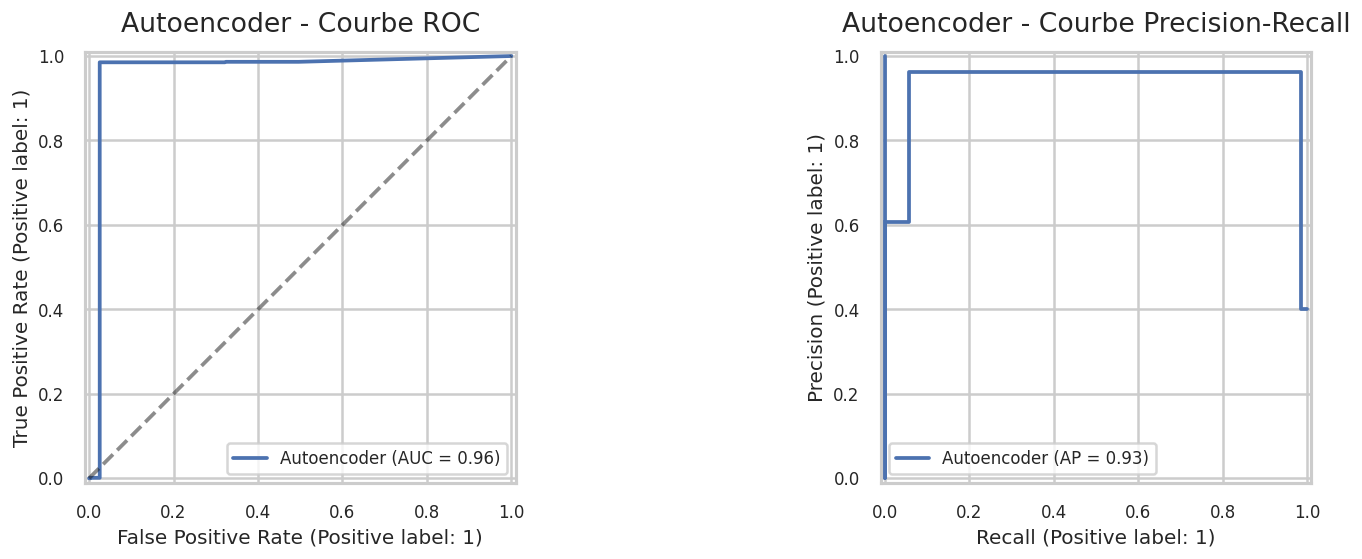

[VAL-DRIVEN on TEST for demo] thr=0.005095 | P=0.963 R=0.985 F1=0.974


In [39]:
# =========================
# == AFTER TRAINING AE  ==
# =========================
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    classification_report,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
import numpy as np

# 1) Erreur de reconstruction (train bénin + test)
train_pred = ae.predict(X_tr, verbose=0)
train_rec = np.mean((X_tr - train_pred) ** 2, axis=1)

test_pred = ae.predict(X_te, verbose=0)
test_rec = np.mean((X_te - test_pred) ** 2, axis=1)

# 2) Sélection du seuil (ici: grille sur test_rec pour démonstration)
#    -> Idéalement, fais-le sur un set de validation (X_val, y_val)
ps = [80, 85, 90, 95, 97, 98, 99, 99.5, 99.9]
ths = sorted(set([np.percentile(test_rec, p) for p in ps] + list(np.linspace(test_rec.min(), test_rec.max(), 100))))

best = {"thr": None, "f1": -1, "precision": 0, "recall": 0}
for thr in ths:
    y_hat = (test_rec > thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_hat, average="binary", zero_division=0
    )
    if f1 > best["f1"]:
        best = {"thr": thr, "f1": f1, "precision": precision, "recall": recall}

threshold = best["thr"]

# 3) Prédictions finales + métriques
test_pred_bin = (test_rec > threshold).astype(int)

detected_anomalies = int(test_pred_bin.sum())
real_anomalies = int(y_test.sum())

acc = accuracy_score(y_test, test_pred_bin)
prec = precision_score(y_test, test_pred_bin, zero_division=0)
rec = recall_score(y_test, test_pred_bin, zero_division=0)
f1 = f1_score(y_test, test_pred_bin, zero_division=0)

if len(np.unique(y_test)) > 1:
    roc_auc = roc_auc_score(y_test, test_rec)
    pr_auc = average_precision_score(y_test, test_rec)
else:
    roc_auc = np.nan
    pr_auc = np.nan

cm = confusion_matrix(y_test, test_pred_bin)

display(Markdown("### Autoencoder - Résumé des performances"))
metrics_ae = pd.DataFrame(
    [
        {
            "Modele": "Autoencoder",
            "Seuil": threshold,
            "Anomalies detectees": detected_anomalies,
            "Anomalies reelles": real_anomalies,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1": f1,
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
        }
    ]
).round(4)
display(metrics_ae)

display(Markdown("#### Rapport de classification"))
report_ae = pd.DataFrame(classification_report(y_test, test_pred_bin, output_dict=True)).T
display(report_ae.round(4))

# Courbes ROC et PR pour des figures exploitables dans le memoire
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
RocCurveDisplay.from_predictions(y_test, test_rec, ax=axes[0], name="Autoencoder")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_title("Autoencoder - Courbe ROC")

PrecisionRecallDisplay.from_predictions(y_test, test_rec, ax=axes[1], name="Autoencoder")
axes[1].set_title("Autoencoder - Courbe Precision-Recall")

plt.tight_layout()
plt.show()

print(
    f"[VAL-DRIVEN on TEST for demo] thr={best['thr']:.6f} | "
    f"P={best['precision']:.3f} R={best['recall']:.3f} F1={best['f1']:.3f}"
)

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay

def plot_cm_and_hist(cm, scores, y_true, threshold, title_prefix, score_label):
    """Affiche une confusion matrix normalisee et la distribution des scores."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Matrice de confusion brute
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["normal", "anomaly"],
    )
    disp.plot(ax=axes[0], colorbar=False, cmap="Blues", values_format="d")
    axes[0].set_title(f"{title_prefix} - Confusion Matrix")
    axes[0].grid(False)

    # Distribution des scores
    scores_benign = scores[y_true == 0]
    scores_mal = scores[y_true == 1]

    axes[1].hist(
        scores_benign,
        bins=70,
        alpha=0.55,
        density=True,
        label="Benign (label=0)",
        color="#4C78A8",
    )
    axes[1].hist(
        scores_mal,
        bins=70,
        alpha=0.55,
        density=True,
        label="Attack (label=1)",
        color="#E45756",
    )
    axes[1].axvline(
        threshold,
        color="#111111",
        linestyle="--",
        linewidth=2,
        label=f"Threshold={threshold:.4f}",
    )

    if len(scores_benign) > 0:
        axes[1].axvline(
            np.median(scores_benign),
            color="#4C78A8",
            linestyle=":",
            linewidth=1.8,
            label="Mediane benign",
        )
    if len(scores_mal) > 0:
        axes[1].axvline(
            np.median(scores_mal),
            color="#E45756",
            linestyle=":",
            linewidth=1.8,
            label="Mediane attack",
        )

    axes[1].set_title(f"{title_prefix} - Distribution des scores")
    axes[1].set_xlabel(score_label)
    axes[1].set_ylabel("Densite")
    axes[1].legend(loc="upper right", frameon=True)

    plt.tight_layout()
    plt.show()

### XGBoost - Resume des performances

,Modele,Seuil,Anomalies detectees,Anomalies reelles,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,0.5000,861,874,0.9941,1.0000,0.9851,0.9925,0.9955,0.9932
1,XGBoost,0.1508,861,874,0.9941,1.0000,0.9851,0.9925,0.9955,0.9932


#### Rapport de classification (XGBoost, thr=0.5)

,precision,recall,f1-score,support
0,0.9902,1.0000,0.9951,"1,312.0000"
1,1.0000,0.9851,0.9925,874.0000
accuracy,0.9941,0.9941,0.9941,0.9941
macro avg,0.9951,0.9926,0.9938,"2,186.0000"
weighted avg,0.9941,0.9941,0.9940,"2,186.0000"


#### Rapport de classification (XGBoost, thr=F1-opt)

,precision,recall,f1-score,support
0,0.9902,1.0000,0.9951,"1,312.0000"
1,1.0000,0.9851,0.9925,874.0000
accuracy,0.9941,0.9941,0.9941,0.9941
macro avg,0.9951,0.9926,0.9938,"2,186.0000"
weighted avg,0.9941,0.9941,0.9940,"2,186.0000"


[XGB] Seuil F1-optimal: 0.150790 | P=1.000 R=0.985 F1=0.993


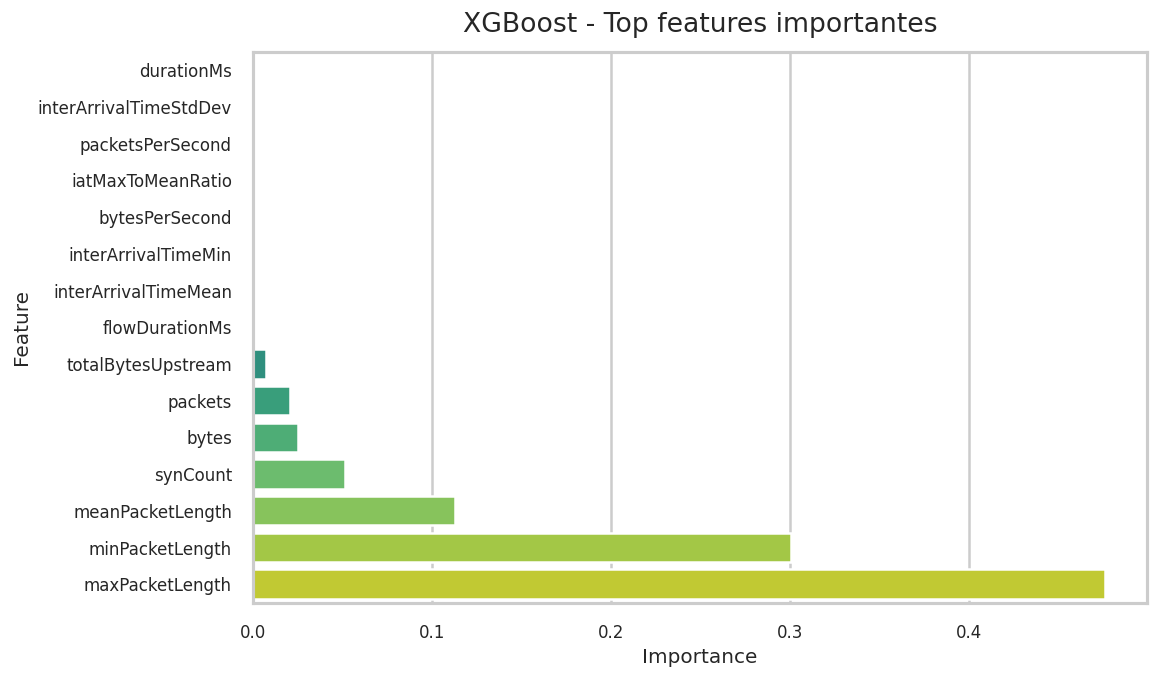

In [41]:
# =========================
# == SUPERVISED: XGBoost ==
# =========================
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support,
)
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Préparer X_train_sup / y_train_sup avec TON preprocess existant
train_df_proc = preprocess(train_df)

# S'assure que toutes les colonnes de features sont là
for col in FEATURE_COLUMNS_FINAL:
    if col not in train_df_proc.columns:
        train_df_proc[col] = 0

X_train_sup_raw = train_df_proc[FEATURE_COLUMNS_FINAL].copy()

# y_train_sup binaire robuste (0/1 ou BENIGN/MALICIOUS)
lab_tr = train_df.get("label")
if lab_tr is None:
    raise KeyError("La colonne 'label' est absente de train_df.")
lab_tr_norm = lab_tr.astype(str).str.strip().str.upper()
mapped_tr = lab_tr_norm.map({"BENIGN": 0, "MALICIOUS": 1})
numeric_tr = pd.to_numeric(lab_tr, errors="coerce")
y_train_sup = mapped_tr.fillna(numeric_tr).fillna(0).astype(int).values

# 2) Mettre X_train_sup dans le même espace que X_te (même pipeline que tu utilises déjà)
X_train_sup_clipped = X_train_sup_raw.clip(lower=0, upper=1e8)
X_train_sup = np.log1p(X_train_sup_clipped)
X_train_sup = np.nan_to_num(X_train_sup, posinf=0, neginf=0)

# ⚠️ IMPORTANT : on réutilise TES objets 'scaler' et 'minmax' déjà fit sur X_tr (bénin)
X_train_sup = scaler.transform(X_train_sup)
X_train_sup = minmax.transform(X_train_sup)

# 3) Gérer le déséquilibre de classes (utile pour IDS)
pos = max(1, int(y_train_sup.sum()))
neg = max(1, int(len(y_train_sup) - pos))
scale_pos_weight = neg / pos

# 4) Modèle XGBoost
xgb = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
)

# 5) Entraînement
xgb.fit(X_train_sup, y_train_sup)

# 6) Évaluation sur TON test final (X_te / y_test)
y_proba = xgb.predict_proba(X_te)[:, 1]

# a) Seuil standard 0.5
y_pred_05 = (y_proba >= 0.5).astype(int)

acc_xgb_05 = accuracy_score(y_test, y_pred_05)
prec_xgb_05 = precision_score(y_test, y_pred_05, zero_division=0)
rec_xgb_05 = recall_score(y_test, y_pred_05, zero_division=0)
f1_xgb_05 = f1_score(y_test, y_pred_05, zero_division=0)
roc_xgb = roc_auc_score(y_test, y_proba)
pr_xgb = average_precision_score(y_test, y_proba)
cm_xgb_05 = confusion_matrix(y_test, y_pred_05)

# b) Seuil optimisé F1
ps = [80, 85, 90, 95, 97, 98, 99, 99.5, 99.9]
ths = sorted(set([np.percentile(y_proba, p) for p in ps] + list(np.linspace(y_proba.min(), y_proba.max(), 200))))
best = {"thr": None, "f1": -1, "precision": 0, "recall": 0}
for thr in ths:
    pred = (y_proba >= thr).astype(int)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="binary", zero_division=0
    )
    if f1 > best["f1"]:
        best = {"thr": thr, "f1": f1, "precision": precision, "recall": recall}

thr_best = best["thr"]
y_pred_best = (y_proba >= thr_best).astype(int)
cm_xgb_best = confusion_matrix(y_test, y_pred_best)

display(Markdown("### XGBoost - Resume des performances"))
metrics_xgb = pd.DataFrame(
    [
        {
            "Modele": "XGBoost",
            "Seuil": 0.5,
            "Anomalies detectees": int((y_pred_05 == 1).sum()),
            "Anomalies reelles": int((y_test == 1).sum()),
            "Accuracy": acc_xgb_05,
            "Precision": prec_xgb_05,
            "Recall": rec_xgb_05,
            "F1": f1_xgb_05,
            "ROC-AUC": roc_xgb,
            "PR-AUC": pr_xgb,
        },
        {
            "Modele": "XGBoost",
            "Seuil": float(thr_best),
            "Anomalies detectees": int((y_pred_best == 1).sum()),
            "Anomalies reelles": int((y_test == 1).sum()),
            "Accuracy": accuracy_score(y_test, y_pred_best),
            "Precision": precision_score(y_test, y_pred_best, zero_division=0),
            "Recall": recall_score(y_test, y_pred_best, zero_division=0),
            "F1": f1_score(y_test, y_pred_best, zero_division=0),
            "ROC-AUC": roc_xgb,
            "PR-AUC": pr_xgb,
        },
    ]
).round(4)
display(metrics_xgb)

display(Markdown("#### Rapport de classification (XGBoost, thr=0.5)"))
report_xgb_05 = pd.DataFrame(classification_report(y_test, y_pred_05, output_dict=True)).T
display(report_xgb_05.round(4))

display(Markdown("#### Rapport de classification (XGBoost, thr=F1-opt)"))
report_xgb_best = pd.DataFrame(classification_report(y_test, y_pred_best, output_dict=True)).T
display(report_xgb_best.round(4))

print(
    f"[XGB] Seuil F1-optimal: {thr_best:.6f} | "
    f"P={best['precision']:.3f} R={best['recall']:.3f} F1={best['f1']:.3f}"
)

# 7) Top features importantes en graphique
try:
    importances = xgb.feature_importances_
    feature_names = np.array(FEATURE_COLUMNS_FINAL)
    topk = min(15, len(importances))
    idxs = np.argsort(importances)[::-1][:topk]

    feat_df = pd.DataFrame(
        {
            "feature": feature_names[idxs],
            "importance": importances[idxs],
        }
    ).sort_values("importance", ascending=True)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")
    plt.title("XGBoost - Top features importantes")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("(Info) Impossible d'afficher les importances XGB:", e)

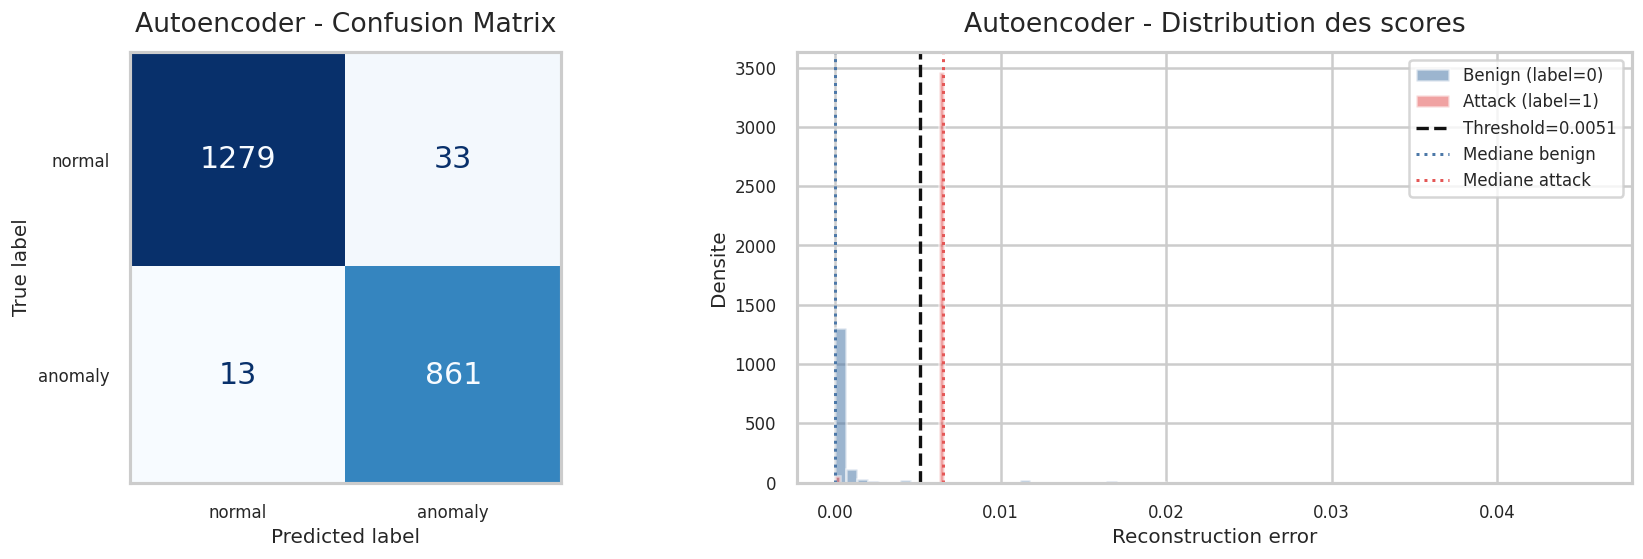

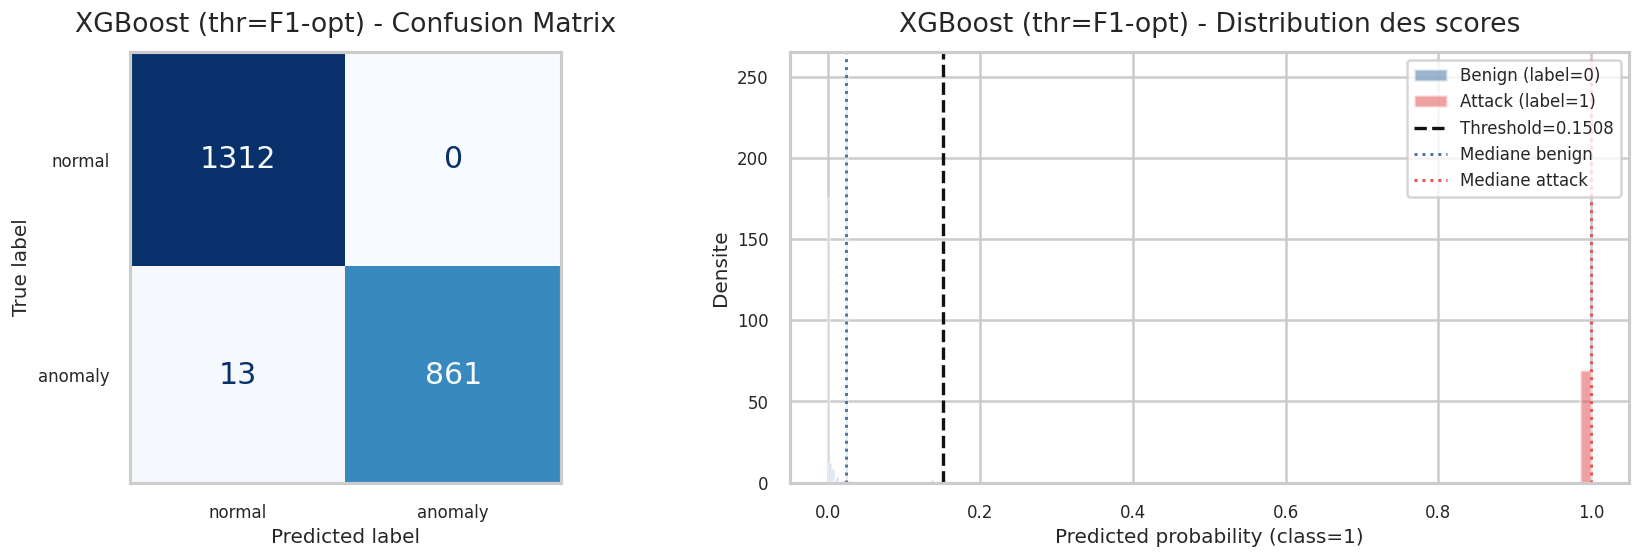

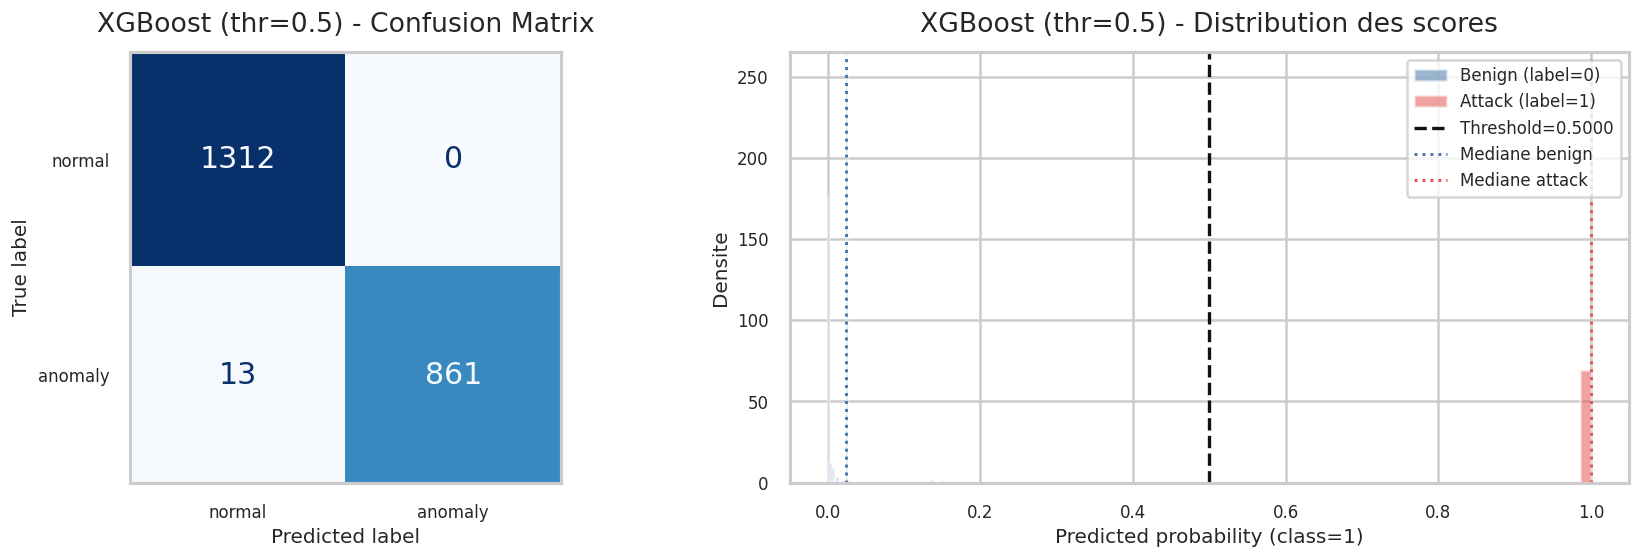

In [42]:
# Autoencoder (au-dessus)
plot_cm_and_hist(
    cm=cm,
    scores=test_rec,
    y_true=y_test,
    threshold=threshold,
    title_prefix="Autoencoder",
    score_label="Reconstruction error"
)

# XGBoost (F1-opt)
plot_cm_and_hist(
    cm=cm_xgb_best,
    scores=y_proba,
    y_true=y_test,
    threshold=thr_best,
    title_prefix="XGBoost (thr=F1-opt)",
    score_label="Predicted probability (class=1)"
)

# XGBoost (seuil 0.5)
plot_cm_and_hist(
    cm=cm_xgb_05,
    scores=y_proba,
    y_true=y_test,
    threshold=0.5,
    title_prefix="XGBoost (thr=0.5)",
    score_label="Predicted probability (class=1)"
)

Variance expliquée PCA: PC1=0.7711, PC2=0.1315, Total=0.9026


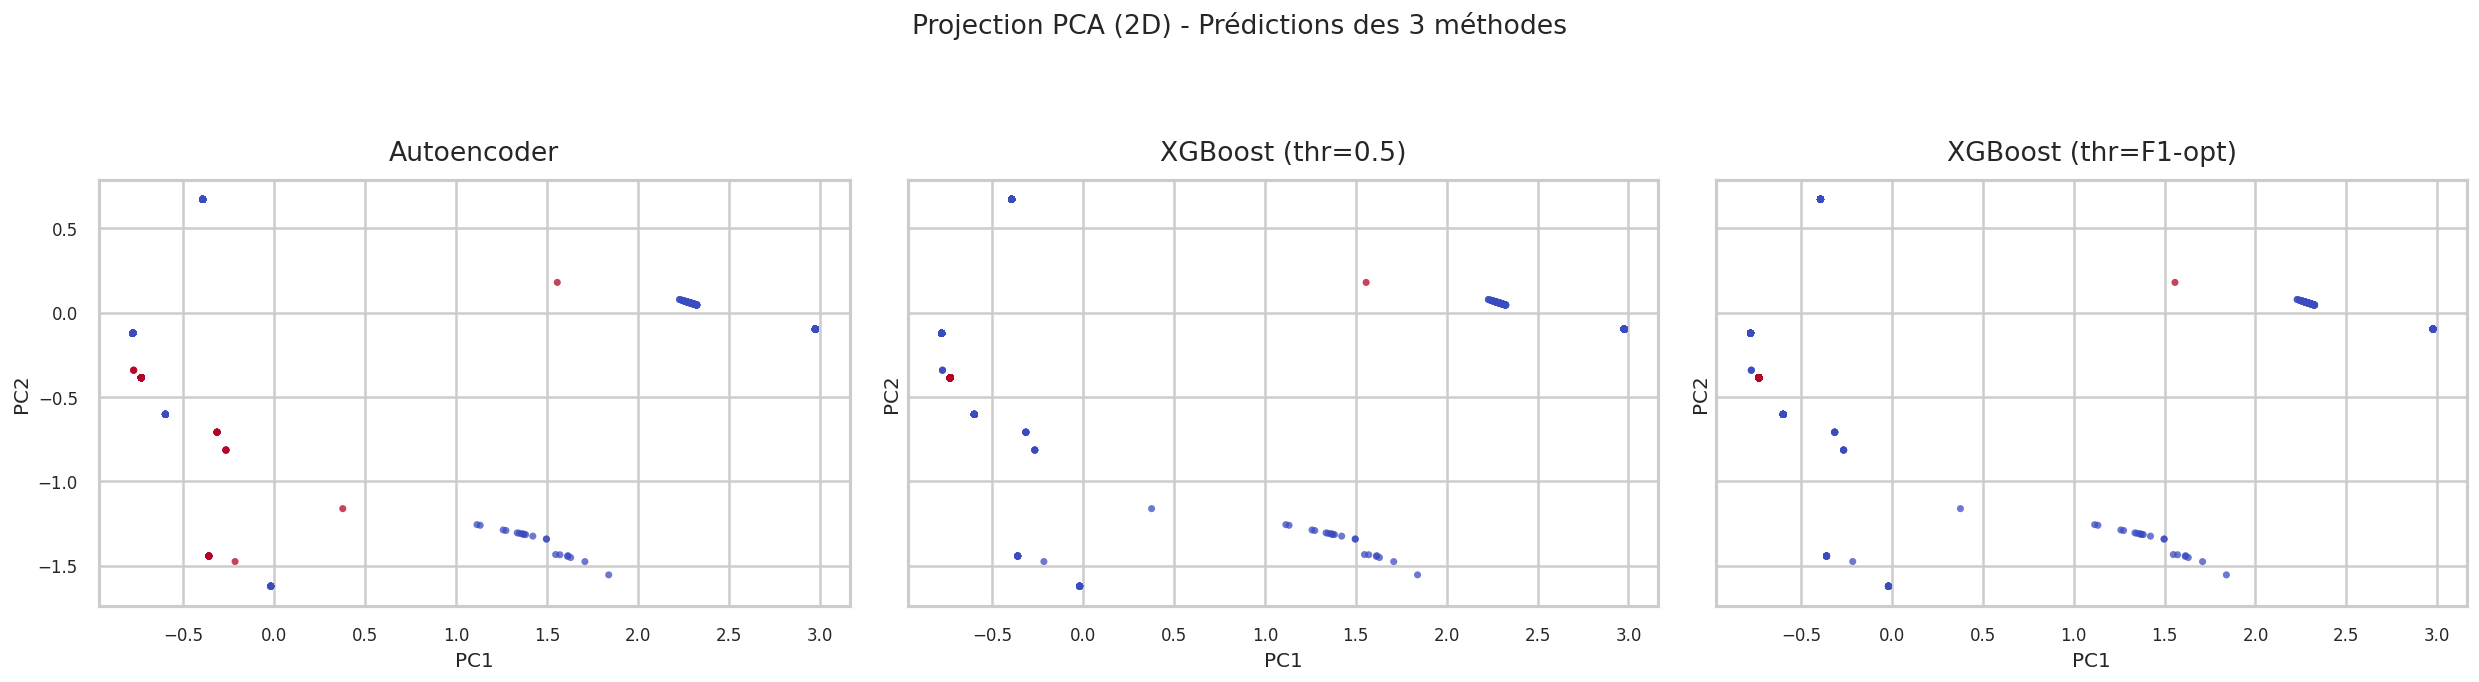

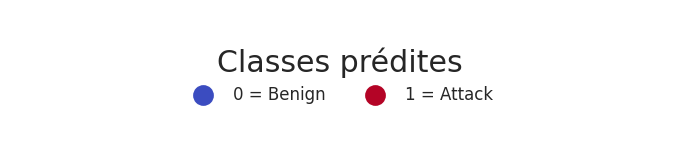

In [47]:
# PCA 2D sur le jeu de test, affichée pour 3 méthodes de prédiction
if "X_te" not in globals():
        raise NameError("La variable 'X_te' est introuvable. Exécute la cellule de scaling avant celle-ci.")

pca_2d = PCA(n_components=2, random_state=42)
X_te_pca = pca_2d.fit_transform(X_te)

print(
        f"Variance expliquée PCA: PC1={pca_2d.explained_variance_ratio_[0]:.4f}, "
        f"PC2={pca_2d.explained_variance_ratio_[1]:.4f}, "
        f"Total={pca_2d.explained_variance_ratio_.sum():.4f}"
)

methods = {
        "Autoencoder": test_pred_bin,
        "XGBoost (thr=0.5)": y_pred_05,
        "XGBoost (thr=F1-opt)": y_pred_best,
}

# -------- Plot principal (sans légende / sans colorbar) --------
fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharex=True, sharey=True)

for ax, (name, pred) in zip(axes, methods.items()):
        pred = np.asarray(pred).astype(int)
        ax.scatter(
                X_te_pca[:, 0],
                X_te_pca[:, 1],
                c=pred,
                cmap="coolwarm",
                s=18,
                alpha=0.75,
                edgecolor="none",
        )
        ax.set_title(name)
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")

fig.suptitle("Projection PCA (2D) - Prédictions des 3 méthodes", y=0.98, fontsize=16)
plt.tight_layout(rect=[0, 0.02, 1, 0.93])
plt.show()

# -------- 2e plot : légende des couleurs uniquement --------
cmap = plt.get_cmap("coolwarm")
color_0 = cmap(0.0)   # classe 0
color_1 = cmap(1.0)   # classe 1

fig_leg, ax_leg = plt.subplots(figsize=(6, 1.6))
ax_leg.scatter([], [], c=[color_0], s=120, label="0 = Benign")
ax_leg.scatter([], [], c=[color_1], s=120, label="1 = Attack")
ax_leg.legend(loc="center", ncol=2, frameon=False, title="Classes prédites")
ax_leg.axis("off")
plt.tight_layout()
plt.show()